# Insurance Data Analysis
This notebook performs exploratory data analysis (EDA) on the cleaned insurance datasets: customers, policies, claims, and payments. 

## Executive Summary

This analysis explores customer, policy, claims, and payment data to evaluate risk, profitability, and key drivers of insurance performance.

**Key Insights:**

- **Regional profitability varies significantly:**  
  BC and AB have higher loss ratios (0.59 and 0.55), indicating lower profitability, while ON and QC perform better (0.44 and 0.43).

- **Home policies show the highest risk per policy:**  
  Although Auto policies generate the most claims overall, Home policies have the highest claims per policy, suggesting greater risk on an individual basis.

- **A small group of customers drives high claim costs:**  
  The top 10 customers each exceed \$10,000 in total claims, highlighting the importance of identifying and managing high-risk customers.

- **Claim amounts are highly skewed:**  
  Most claims are relatively small, with a few large claims driving the upper range, emphasizing the importance of outlier management in risk analysis.

- **Customer base is evenly distributed across regions and income levels:**  
  No single region or income group dominates, supporting balanced portfolio analysis.

- **Premiums are consistent across policy types:**  
  Despite differences in claim frequency, average premiums are similar across Auto, Home, and Life policies, suggesting potential opportunities for pricing optimization.

**Business Implications:**

- Adjust pricing or underwriting strategies in higher-risk regions (BC, AB)  
- Reassess risk and pricing for Home policies  
- Monitor and manage high-claim customers more closely  
- Account for claim outliers in forecasting and risk modeling  

## Setup

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Setting visualization style
sns.set(style = 'whitegrid')

The cleaned tables are imported and date columns are parsed for proper time-based analysis.

In [2]:
# Loading cleaned datasets
customers = pd.read_csv("data/clean/customers_clean.csv", parse_dates = ['join_date'])
policies = pd.read_csv("data/clean/policies_clean.csv", parse_dates = ['start_date', 'end_date'])
claims = pd.read_csv("data/clean/claims_clean.csv", parse_dates = ['claim_date'])
payments = pd.read_csv("data/clean/payments_clean.csv", parse_dates = ['payment_date'])

## Customer Demographics
We explore customer demographics to understand the distribution of **age, income, and region**. 
This can help identify the main customer segments for targeted insurance products.

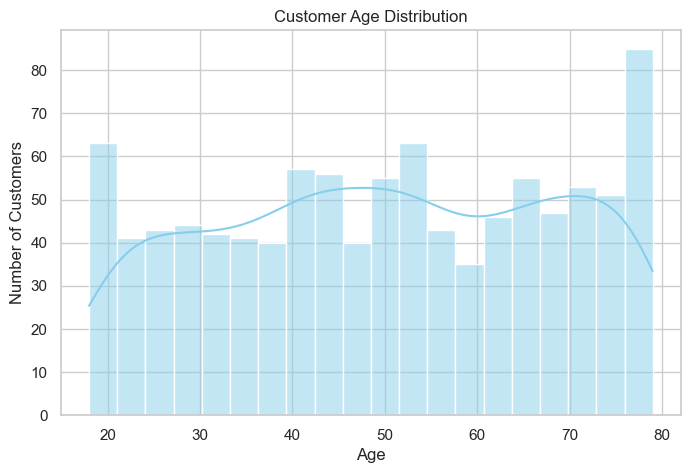

In [3]:
# Customer age distribution
plt.figure(figsize = (8,5))
sns.histplot(customers['age'], bins = 20, kde = True, color = 'skyblue')
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

The histogram shows the distribution of customer ages, with a KDE (kernel density estimate) overlaid.  

**Observations:**  
- The first “peak” is actually a plateau: the first bin is noticeably higher than the next six bins, suggesting a slightly higher concentration of younger customers, but not a sharply defined group.  
- The KDE smooths these fluctuations, showing a gentle wave with a central rise and a smaller peak near the older ages.  
- The last bin is taller than the preceding bins, but the KDE drops toward the end, indicating that this edge may be influenced by the binning rather than a large number of extremely old customers.  

**Interpretation:**  
- The distribution shows **a fairly even spread of ages with some clustering at the younger and older ends**, rather than sharply distinct age groups.
- This insight could guide customer segmentation or marketing strategies, ensuring offerings are appropriate across the age spectrum.

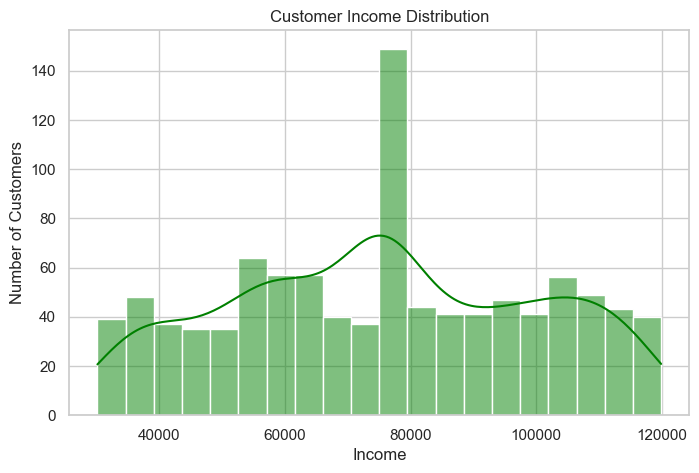

In [4]:
# Income Distribution
plt.figure(figsize = (8,5))
sns.histplot(customers['income'], bins = 20, kde = True, color = 'green')
plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.show()

The histogram shows the distribution of customer incomes.  

**Observations:**  
- The distribution is fairly even across most income ranges, with a small peak around \$60,000.  
- One bin, just before \$80,000, is noticeably higher than the others, more than **double the height** of any other bin. This suggests a concentration of customers earning in that specific income bracket.  
- Aside from that spike, the rest of the histogram shows a relatively smooth spread, without extreme skew or obvious outliers.  

**Interpretation:**  
- The spike near \$80,000 may indicate **a common income level among customers**, perhaps due to a regional or occupational pattern in the dataset.  
- Understanding these income concentrations can help in **targeting premium plans, risk assessment, or marketing strategies**.  
- Overall, the fairly even distribution suggests a diverse customer base in terms of income.

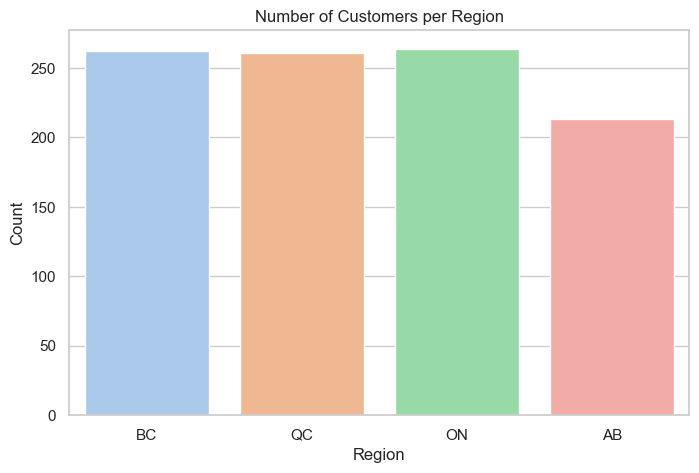

In [5]:
# Customers per region
plt.figure(figsize = (8,5))
sns.countplot(data = customers, x = 'region', hue = 'region', palette = 'pastel', legend = False)
plt.title("Number of Customers per Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

The countplot shows the number of customers in each region.  

**Observations:**  
- **BC, QC, and ON** each have just over 250 customers, indicating a roughly equal representation across these regions.  
- **AB** has slightly fewer customers, just over 200.  
- No region dominates the dataset, and there are no regions with very few customers.  

**Interpretation:**  
- The fairly balanced regional distribution suggests that the customer base is **geographically diverse**, which is useful for analyzing regional trends in premiums, claims, or marketing impact.  
- AB’s slightly lower count might warrant consideration if calculating **region-specific metrics**, as smaller sample sizes can slightly increase variability in averages or ratios.

## Policy Analysis
We analyze **policy distribution** and **premium amounts** by type to identify which products generate the most revenue.

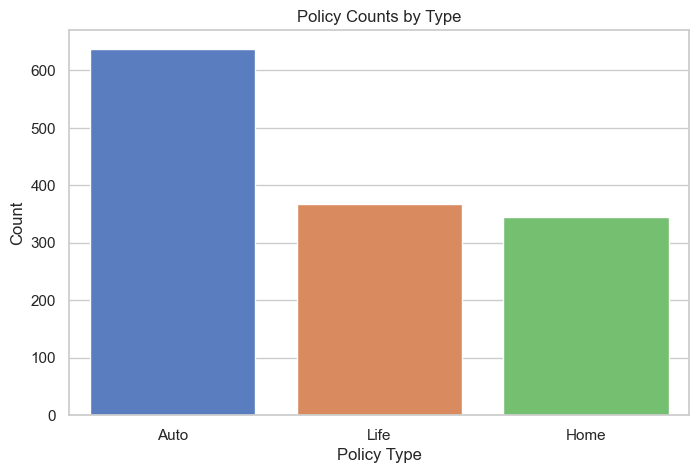

In [6]:
# Number of policies by type
plt.figure(figsize = (8,5))
sns.countplot(data = policies, x = 'policy_type', hue = 'policy_type', palette = 'muted', legend = False)
plt.title("Policy Counts by Type")
plt.xlabel("Policy Type")
plt.ylabel("Count")
plt.show()

The countplot shows the number of policies by type.  

**Observations:**  
- **Auto policies** are the most common, with approximately 650 policies.  
- **Life policies** have about 375 policies, and **Home policies** roughly 350.  
- Auto policies clearly outnumber the other two types, while Home and Life policies have a similar count.  

**Interpretation:**  
- The distribution indicates that **Auto insurance is the most popular product** among customers in this dataset, which could reflect market demand or the company’s focus.  
- When analyzing **claims, premiums, or customer retention**, it may be useful to **segment by policy type**, since Auto policies represent a significant portion of the portfolio and may drive overall trends.  

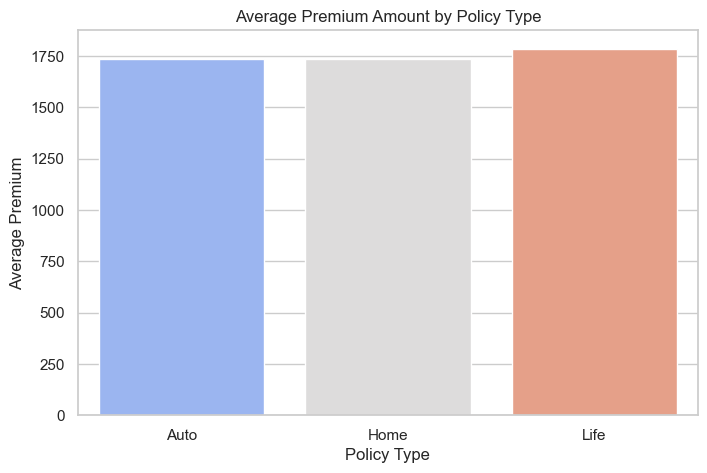

In [7]:
# Average premium by policy type
avg_premium = policies.groupby('policy_type')['premium_amount'].mean().reset_index()
plt.figure(figsize = (8,5))
sns.barplot(data = avg_premium, x = 'policy_type', y = 'premium_amount', hue = 'policy_type', palette = 'coolwarm', legend = False)
plt.title("Average Premium Amount by Policy Type")
plt.xlabel("Policy Type")
plt.ylabel("Average Premium")
plt.show()

The barplot shows the **average premium amount** for each policy type.  

**Observations:**  
- Despite the differences in the number of policies per type, **Auto, Home, and Life policies all have nearly the same average premium**.  
- There are no obvious outliers or significant gaps between the averages.  

**Interpretation:**  
- This suggests that the company **prices its products consistently** across policy types, at least in terms of average premiums.  
- For further analysis, it may be useful to examine **premium distributions or variability** within each type, since the average alone does not capture the range of premiums or extreme values.  
- Maintaining similar average premiums could indicate a **balanced risk-pricing strategy** across different product lines.  

## Claims Analysis
Exploring **claim counts by type** and **claim amounts** reveals trends in claims frequency and magnitude, 
highlighting potential areas for risk management.

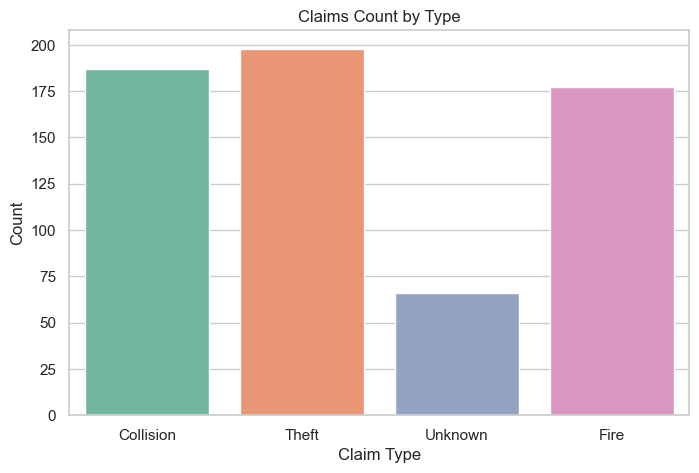

In [8]:
# Claims by type
plt.figure(figsize = (8,5))
sns.countplot(data = claims, x = 'claim_type', hue = 'claim_type', palette = 'Set2', legend = False)
plt.title("Claims Count by Type")
plt.xlabel("Claim Type")
plt.ylabel("Count")
plt.show()

The countplot shows the number of claims for each claim type after cleaning broken keys.

Observations:

- Collision claims are just under halfway between 175 and 200 (~187).  
- Theft claims are just under 200 (~198).  
- Fire claims are just over 175 (~177).  
- Unknown claims are just over halfway between 50 and 75 (~63).  
- The distribution among known claim types remains fairly even.

Interpretation:

- The relatively balanced counts across Collision, Theft, and Fire suggest no single claim type dominates the risk profile.  
- The Unknown claims represent missing or incomplete data and should be considered carefully when calculating loss ratios or risk metrics.  
- Depending on business requirements, unknown claims could be excluded or analyzed separately to avoid skewing insights.

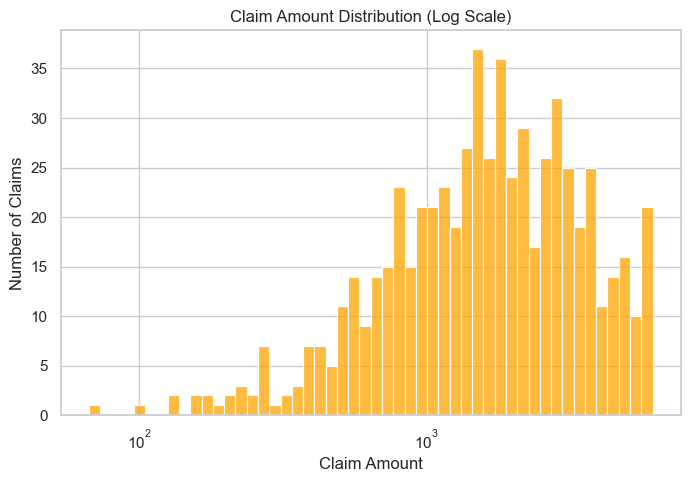

In [9]:
# Claim Amount Distribution (Log scale to handle outliers)
plt.figure(figsize = (8,5))
sns.histplot(claims['claim_amount'], bins = 50, log_scale = True, color = 'orange')
plt.title("Claim Amount Distribution (Log Scale)")
plt.xlabel("Claim Amount")
plt.ylabel("Number of Claims")
plt.show()

### Claim Amount Distribution (Log Scale)

The histogram shows the distribution of claim amounts using a logarithmic scale.

**Observations:**  
- The distribution shows a concentration of values across the mid-range, with a tail extending to the left on the log scale.  
- Extreme values are less visually dominant due to the logarithmic transformation.  

**Interpretation:**  
- Claim amounts in insurance datasets are typically **right-skewed**, with many smaller claims and a few very large ones.  
- The use of a log scale reduces the visual impact of large claims, making it easier to observe the spread of the majority of the data.  
- The apparent left tail in the log-transformed plot reflects this transformation rather than indicating that the original data is left-skewed.  
- This suggests the presence of **high-value claims**, which are important for risk and loss analysis.

## Payment Analysis
Analyzing **payments per policy** shows cash flow patterns and highlights high-value policies.

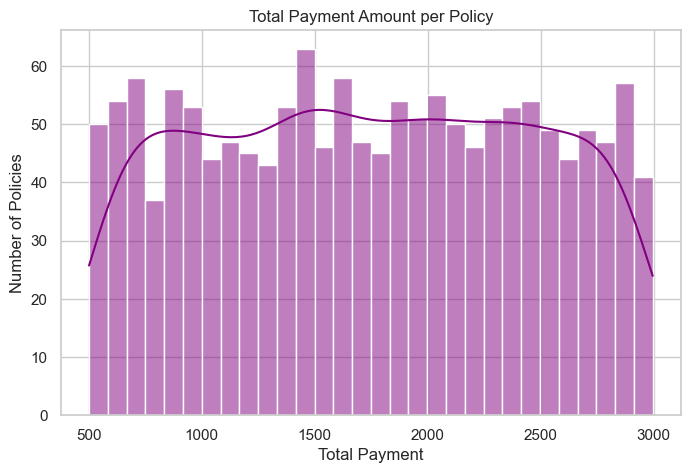

In [10]:
# Average payment amount per policy
avg_payment = payments.groupby('policy_id')['payment_amount'].sum().reset_index()
plt.figure(figsize = (8,5))
sns.histplot(avg_payment['payment_amount'], bins = 30, kde = True, color = 'purple')
plt.title("Total Payment Amount per Policy")
plt.xlabel("Total Payment")
plt.ylabel("Number of Policies")
plt.show()

### Total Payment Amount per Policy

The histogram shows the distribution of total payment amounts per policy, with a KDE (kernel density estimate) overlaid.

**Observations:**  
- The histogram displays multiple fluctuations across bins, with no clearly dominant peak.  
- The KDE line remains relatively flat across most of the range.  

**Interpretation:**  
- The absence of a strong peak suggests that total payment amounts are **fairly evenly distributed** across policies. 
- The smoothing applied by the KDE may also mask smaller variations visible in the histogram.  
- Overall, there is no strong clustering, indicating a **broad spread of payment totals** across policies.

## SQL Analysis

To complement the Python-based analysis, SQL queries were used to extract key business insights from the dataset.

In [11]:
# Creating in-memory SQLite DB
conn = sqlite3.connect(':memory:')

# Loading tables into SQL
customers.to_sql('customers', conn, index=False)
policies.to_sql('policies', conn, index=False)
claims.to_sql('claims', conn, index=False)
payments.to_sql('payments', conn, index=False)

18000

### Loss Ratio by Region

This query calculates the total premiums, total claims, and **loss ratio** for each region.

**Business purpose:**  
Insurance companies need to know which regions are most profitable and which are riskier. The **loss ratio** (claims ÷ premiums) is a key metric for underwriting decisions and pricing strategies. Regions with high loss ratios indicate higher risk or mispriced policies, while low loss ratios indicate profitable regions.

**Why sort by loss ratio:**  
Sorting by the loss ratio highlights **riskier regions first**, which is more actionable for business decisions than sorting by total premiums. It helps identify areas that may require attention in pricing, policy design, or risk mitigation.

In [12]:
biz_performance_query = """
    SELECT
        c.region,
        COUNT(DISTINCT p.policy_id) AS num_policies,
        SUM(p.premium_amount) AS total_premiums,
        SUM(cl.claim_amount) AS total_claims,
        ROUND(SUM(cl.claim_amount) * 1.0 / SUM(p.premium_amount), 2) AS loss_ratio  -- *1.0 ensures float division
    FROM customers AS c
    LEFT JOIN policies AS p
    ON c.customer_id = p.customer_id
    LEFT JOIN claims AS cl
    ON p.policy_id = cl.policy_id
    GROUP BY c.region
    ORDER BY loss_ratio DESC;
    """

pd.read_sql(biz_performance_query, conn)

,region,num_policies,total_premiums,total_claims,loss_ratio
0,BC,353,672155,396527.7744,0.59
1,AB,295,563836,308584.1005,0.55
2,ON,345,657910,288132.0422,0.44
3,QC,357,686915,297704.6466,0.43


This table compares the number of policies, total premiums, total claims, and resulting loss ratio across regions.

**Observations:**  
- **BC** has the highest loss ratio at **0.59**, followed by **AB** at **0.55**.  
- **ON** and **QC** have lower loss ratios at **0.44** and **0.43**, respectively.  
- Total premiums and policy counts are relatively similar across regions, indicating a fairly balanced portfolio distribution.  

**Interpretation:**  
- **BC and AB appear to be higher-risk regions**, as a larger proportion of premiums is being paid out in claims.  
- **ON and QC are more profitable regions**, with lower loss ratios indicating better underwriting performance.  
- Since policy counts are similar across regions, these differences are likely driven by **claim frequency or severity**, rather than exposure differences.  

**Business Implications:**  
- The company may consider **adjusting pricing or underwriting criteria** in BC and AB to improve profitability.  
- Further analysis could investigate whether higher loss ratios are driven by specific **policy types or claim categories** within those regions.  
- ON and QC could serve as benchmarks for **profitable risk management strategies**.

### Claim Frequency by Policy Type

This query counts claims per policy type and calculates the average number of claims per policy. 

**Business purpose:**  
Understanding which policy types generate more claims helps the company evaluate product risk, adjust premiums, or design new coverage options. High claims per policy could signal a need for stricter underwriting or customer education.

In [13]:
claim_frequency_query = """
    SELECT
        p.policy_type,
        COUNT(cl.claim_id) AS total_claims,
        COUNT(DISTINCT p.policy_id) AS num_policies,
        ROUND(COUNT(cl.claim_id) * 1.0 / COUNT(DISTINCT p.policy_id), 2) AS claims_per_policy  -- *1.0 ensures float division
    FROM policies AS p
    LEFT JOIN claims AS cl
    ON p.policy_id = cl.policy_id
    GROUP BY p.policy_type
    ORDER BY claims_per_policy DESC;
    """

pd.read_sql(claim_frequency_query, conn)

,policy_type,total_claims,num_policies,claims_per_policy
0,Home,182,345,0.53
1,Auto,292,638,0.46
2,Life,154,367,0.42


This table shows the total number of claims, number of policies, and average claims per policy for each policy type.

**Observations:**  
- **Auto policies** have the highest total number of claims (292), but not the highest claims per policy.  
- **Home policies** have the highest claims per policy at **0.53**, followed by **Auto (0.46)** and **Life (0.42)**.  
- The number of policies differs across types, with Auto having the largest share.  

**Interpretation:**  
- Although Auto policies generate the most claims overall, this is largely due to their **higher volume of policies**, not a higher risk per policy.  
- **Home policies appear to be the riskiest on a per-policy basis**, with the highest claim frequency.  
- **Life policies have the lowest claim frequency**, suggesting lower relative risk in terms of claim occurrence.  

**Business Implications:**  
- The company may want to **review pricing or underwriting for Home policies**, as they generate more claims per policy.  
- Auto policies should still be closely monitored due to their **large contribution to total claim volume**, which can significantly impact overall losses.  
- Life policies may offer more stable performance, but further analysis of **claim severity** would be needed to fully assess profitability.

### Top Customers by Claim Amount

This query identifies the top 10 customers with the highest total claim amounts. 

**Business purpose:**  
Highlighting customers with unusually high claims helps insurers detect potential fraud, assess retention strategies, and prioritize high-risk client management. It also aids in forecasting payouts and capital allocation.

In [14]:
top_customers_query = """
    SELECT
        c.customer_id,
        SUM(cl.claim_amount) AS total_claims
    FROM customers AS c
    JOIN policies AS p
    ON c.customer_id = p.customer_id
    JOIN claims AS cl
    ON p.policy_id = cl.policy_id
    GROUP BY c.customer_id
    ORDER BY total_claims DESC
    LIMIT 10;
    """

pd.read_sql(top_customers_query, conn)

,customer_id,total_claims
0,787,15661.7361
1,893,14688.9661
2,136,12275.3500
3,249,11270.6600
4,237,10320.0100
5,384,10223.3700
6,989,10184.0300
7,376,10119.4961
8,363,10116.5200
9,700,10060.3300


This table identifies the customers with the highest total claim amounts.

**Observations:**  
- The top 10 customers each have total claims exceeding \$10,000.  
- The highest claimant (Customer 787) has over \$15,700 in claims.  
- The difference between the top and lower entries in the top 10 is relatively small, indicating a cluster of high-claim customers rather than a single extreme outlier.  

**Interpretation:**  
- A small group of customers contributes disproportionately to total claim payouts, which is typical in insurance datasets.  
- These customers may represent **higher-risk profiles**, either due to claim frequency, claim severity, or both.  
- The relatively tight range suggests that **high-cost customers are not isolated incidents**, but part of a broader segment.  

**Business Implications:**  
- The company may consider **flagging high-claim customers for review**, including underwriting adjustments or policy conditions.  
- Further analysis could explore whether these customers share common characteristics (e.g., region, policy type), which could help refine **risk segmentation strategies**.  
- Monitoring high-cost customers is important for **controlling overall loss exposure** and improving profitability.

## Conclusion

This analysis examined customer demographics, policy characteristics, claims behavior, and payment patterns to better understand the key drivers of risk and profitability.

The results show that while the portfolio is broadly balanced across regions and policy types, there are meaningful differences in **loss ratios, claim frequency, and high-cost customers** that impact overall performance. In particular, regional variation and higher claim frequency in certain policy types highlight opportunities for more targeted risk management.

Throughout the analysis, data quality considerations such as missing values, inconsistent date formats, and outliers were identified and addressed to ensure reliable results.

## Next Steps

Further analysis could provide deeper insights, including:

- Investigating **claim severity by policy type and region**  
- Analyzing **customer-level characteristics** (e.g., age, income) to refine risk segmentation  
- Building a **predictive model** to estimate claim likelihood or expected loss  
- Evaluating **pricing strategies** to better align premiums with observed risk  

---

This project demonstrates an end-to-end workflow including **data cleaning, exploratory analysis, visualization, and SQL-based business analysis**, with a focus on translating data into actionable insights.